In [1]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install yfinance
!pip install torch

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
#working with arrays, dataframes from yahoo. visualization with matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
#build, train neural network with pytorch

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
#scale and evaluate our data here

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [4]:
ticker = 'MSFT'
df = yf.download(ticker, '2020-01-01')
df

/var/folders/2j/_8mybkvj02xcyn7_s36ccv400000gn/T/ipykernel_1278/28875369.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2020-01-02,152.505676,152.610120,150.331371,150.758634,22622100
2020-01-03,150.606720,151.869532,150.075013,150.321887,21116200
2020-01-06,150.996033,151.062503,148.603335,149.144547,20813700
2020-01-07,149.619263,151.603675,149.372403,151.271365,21634100
2020-01-08,152.002457,152.676595,149.970567,150.901055,27746500
...,...,...,...,...,...
2026-01-05,472.850006,476.070007,469.500000,474.059998,25250300
2026-01-06,478.510010,478.739990,469.750000,473.799988,23037700


<Axes: xlabel='Date'>

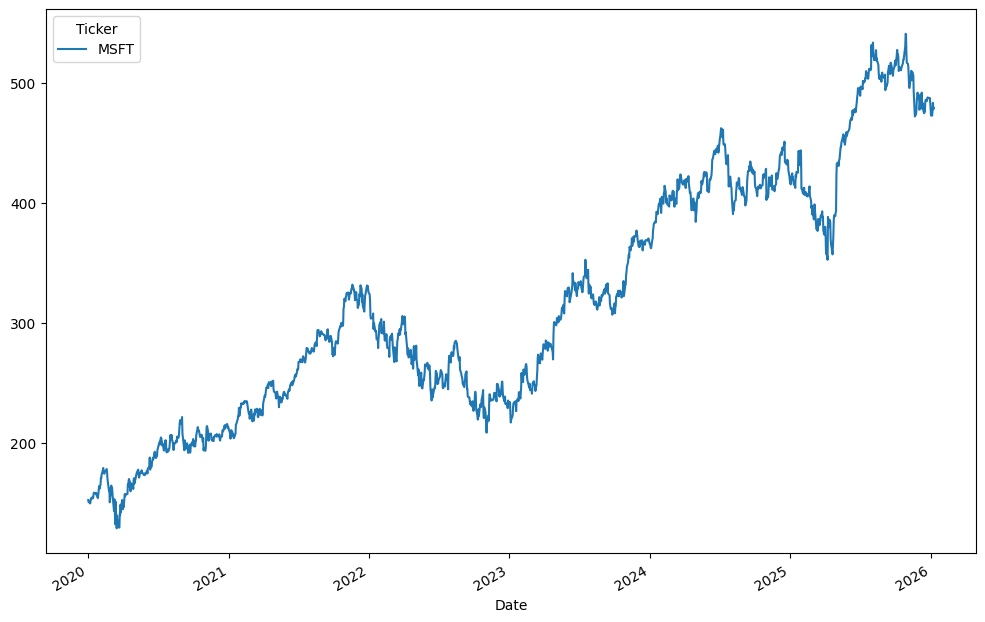

In [5]:
df.Close.plot(figsize=(12,8))

In [6]:
scaler = StandardScaler()
df['Close']= scaler.fit_transform(df['Close'])
df.Close

Ticker,MSFT
Date,
2020-01-02,-1.619194
2020-01-03,-1.637911
2020-01-06,-1.634074
2020-01-07,-1.647643
2020-01-08,-1.624154
...,...
2026-01-05,1.538211
2026-01-06,1.593997
2026-01-07,1.642884


In [7]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])
data = np.array(data)
data

#Why is it in the form of sliding windows?:
#Because stock prices are time series. The window slides one day at a time. 
#Each new window overlaps with the previous one. This allows the model to learn temporal dependencies"""

#our array.shape is (N, 30, 1)
#N = number of samples (how many sliding windows you created)
#30 = sequence length (30 days per sample)
#1 = features per time step (just “Close”)

array([[[-1.61919417],
        [-1.63791082],
        [-1.63407365],
        ...,
        [-1.39627815],
        [-1.39375122],
        [-1.40310984]],

       [[-1.63791082],
        [-1.63407365],
        [-1.64764348],
        ...,
        [-1.39375122],
        [-1.40310984],
        [-1.38776204]],

       [[-1.63407365],
        [-1.64764348],
        [-1.62415404],
        ...,
        [-1.40310984],
        [-1.38776204],
        [-1.37016763]],

       ...,

       [[ 1.53101542],
        [ 1.54954529],
        [ 1.57901548],
        ...,
        [ 1.53909765],
        [ 1.53821062],
        [ 1.59399722]],

       [[ 1.54954529],
        [ 1.57901548],
        [ 1.66289256],
        ...,
        [ 1.53821062],
        [ 1.59399722],
        [ 1.64288431]],

       [[ 1.57901548],
        [ 1.66289256],
        [ 1.72705706],
        ...,
        [ 1.59399722],
        [ 1.64288431],
        [ 1.59005447]]])

In [8]:
#Create the model

class PredictionModel(nn.Module):

    #our lstm based architecture:
    def __init__ (self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self). __init__()
        
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        
        self.lstm =nn.LSTM(input_dim, hidden_dim, num_layers, batch_first = True)
        
        #Fully connected (linear) layer. self.fc is the translator that turns the last short-term memory into the final prediction.
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        #When you use the LSTM in forward(), it needs starting values for its two memories: Hidden state and Cell state 
        #If you don’t pass them, PyTorch will create them as zero tensors for you by default. In your code, you’re manually creating them so you have explicit control.
        
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        #(number of LSTM layers, batch size, size of hidden state vector, put it on CPU or GPU)
        #this creates one blank page for each lstm layer and sequence in the batch
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) #this maps the last hidden state → a prediction.

        return out


In [9]:
model = PredictionModel(input_dim =1, hidden_dim=32, num_layers=2, output_dim=1).to(device)
#send the model to the device (cpu) because the model has to be where the tensors are, otherwise it wouldn't work

In [10]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
#for the first dimention, take until train_size, for the second, all of it except the last one, for the third all of it)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)

X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1:, :]).type(torch.Tensor).to(device)

#in train_test_split(...) we shuffle and then get any 80% but here we want the first 80% because we're making predictions sequentially

In [11]:
#Train the model

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01) 
#model.parameters() tells Adam which weights to update (all trainable parameters of your model).

num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train) #Forward pass using the current weights. here PyTorch calls your model’s forward() method under the hood. 
    loss = criterion(y_train_pred, y_train)
    optimizer.zero_grad() #Clears old gradients from the previous step (not the weights)
    loss.backward() 
    optimizer.step() 

In [12]:
#Testing part: Inverse-scaling and Evaluation

model.eval() 
#Some layers like Dropout and BatchNorm behave differently in training vs. testing. 
#so, this line puts the model in evaluation mode instead of training mode.

with torch.no_grad():
    y_train_pred = model(X_train)
    y_test_pred  = model(X_test)
#You tell PyTorch: “I only want predictions. Do NOT compute gradients.”


y_train_pred_np = y_train_pred.cpu().numpy().reshape(-1, 1)
y_train_np      = y_train.cpu().numpy().reshape(-1, 1)
y_test_pred_np  = y_test_pred.cpu().numpy().reshape(-1, 1)
y_test_np       = y_test.cpu().numpy().reshape(-1, 1)
"""You did four things at once above:
.cpu() → move data off GPU
.numpy() → convert to NumPy for sklearn
.reshape(-1, 1) → make it 2D
Flattened useless dimensions (e.g. (N,1,1) → (N,1))
because StandardScaler.inverse_transform() only accepts 2D NumPy arrays"""


"""During training, you normalized prices.
Now you are saying:
“Give me the predictions back in REAL stock price values”:"""
y_train_pred_inv = scaler.inverse_transform(y_train_pred_np)
y_train_inv      = scaler.inverse_transform(y_train_np)
y_test_pred_inv  = scaler.inverse_transform(y_test_pred_np)
y_test_inv       = scaler.inverse_transform(y_test_np)

train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

print(train_rmse)
print(test_rmse)

0.053735841295509956
0.12648713462181738


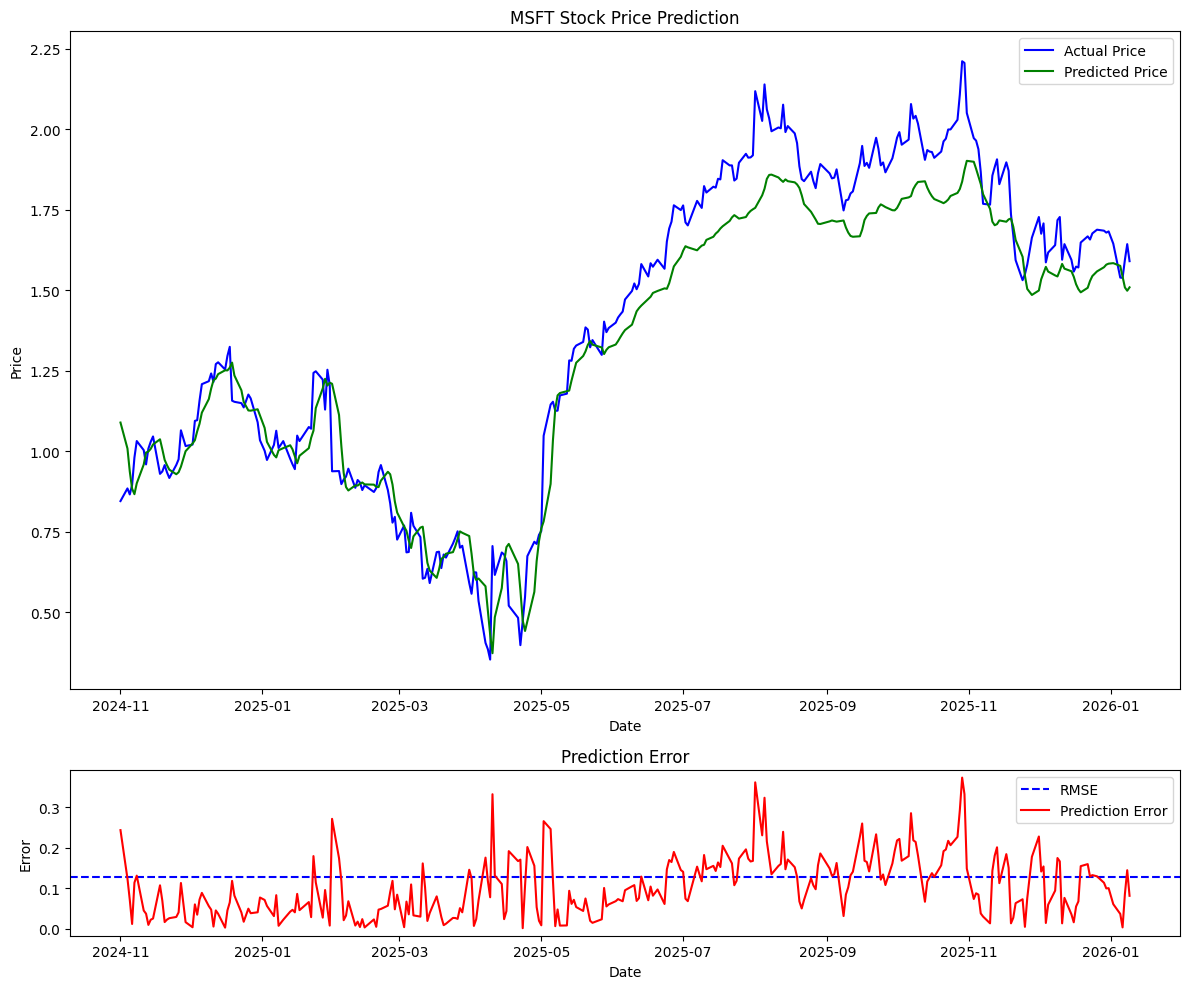

In [13]:
# --- Fix shapes for plotting ---
y_test_plot      = y_test.reshape(-1)        # (N, 1, 1) → (N,)
y_test_pred_plot = y_test_pred.reshape(-1)   # (N, 1, 1) → (N,)

# --- Plotting ---
fig = plt.figure(figsize=(12, 10)) #create a figure of 12-10 size (the below box)
gs = fig.add_gridspec(4, 1) #You’re using a GridSpec (gs = fig.add_gridspec(4, 1)) → that splits your figure into 4 rows × 1 column.

# Top panel: Actual vs Predicted
ax1 = fig.add_subplot(gs[:3, 0]) #gs[:3, 0] means: “take the top 3 rows, column 0” → this creates the top chart in your figure.
ax1.plot(df.iloc[-len(y_test):].index, y_test_plot, color='blue', label='Actual Price') 
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred_plot, color='green', label='Predicted Price')
ax1.legend() #shows the legend (the top-left box)
ax1.set_title(f"{ticker} Stock Price Prediction")
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

# Bottom panel: Prediction Error
ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df.iloc[-len(y_test):].index, abs(y_test_plot - y_test_pred_plot), 'r', label='Prediction Error')
#abs(y_test_plot - y_test_pred_plot) is the absolute error at each time step:
ax2.legend()
ax2.set_title('Prediction Error')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error')

plt.tight_layout()
plt.show()
